Accuracy: 0.4

Classification Report:
              precision    recall  f1-score   support

      Normal       0.50      0.29      0.37        24
Cyber Attack       0.35      0.56      0.43        16

    accuracy                           0.40        40
   macro avg       0.42      0.43      0.40        40
weighted avg       0.44      0.40      0.39        40



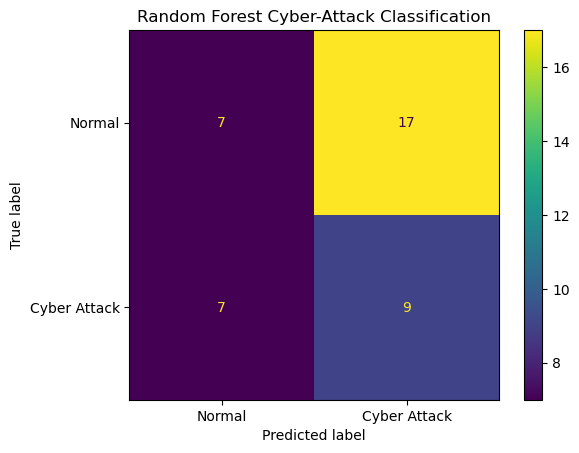

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import ConfusionMatrixDisplay

# Create sample cybersecurity dataset
np.random.seed(42)

data = pd.DataFrame({
    "Packet_Count": np.random.randint(100, 2000, 200),
    "Packet_Size": np.random.randint(100, 1500, 200),
    "Connection_Duration": np.random.randint(1, 300, 200),
    "Attack": np.random.randint(0, 2, 200)
})

# Features and target
X = data[
    ["Packet_Count", "Packet_Size", "Connection_Duration"]
]

y = data["Attack"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Normal", "Cyber Attack"]
    )
)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Normal", "Cyber Attack"]
)

plt.title("Random Forest Cyber-Attack Classification")
plt.show()